# Superstore Sales & Profit Analysis
### End-to-End Data Analytics Project — Python + SQL + Power BI

**Dataset:** Sample Superstore (9,994 orders | 2014–2017 | US retail sales)

**What this project covers:**
1. **Python (Pandas)** — load, clean, and engineer features from raw retail order data
2. **Exploratory Data Analysis (EDA)** — visual analysis of sales, profit, and customer behavior
3. **SQL** — load the cleaned data into a real relational database (SQLite) and answer business questions with SQL queries
4. **Power BI** — export a model-ready dataset and build an interactive dashboard (step-by-step guide included separately)

**Author's workflow:** Jupyter Notebook → SQLite database → Power BI Desktop

---


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load the Data

The original file (`Sample_Superstore.xls`) is a legacy Excel 97-2003 file. The two easiest ways to load it:

- **Option A (recommended, no extra installs):** load the pre-converted `Sample_Superstore.csv` (included in this project folder).
- **Option B:** load the `.xls` directly — this needs the `xlrd` engine: `pip install xlrd`

Both give you the identical 9,994 rows × 21 columns.


In [6]:
# Option A: Load from CSV (recommended)
df = pd.read_excel(r"Sample_Superstore.xls")

# Option B (uncomment if you have xlrd installed and want to read the .xls directly):
# df = pd.read_excel("Sample_Superstore.xls", engine="xlrd")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 9994 rows x 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## 2. Data Cleaning

Steps performed:
1. Check for missing values and duplicate rows
2. Convert `Order Date` / `Ship Date` from text to proper `datetime`
3. Engineer new analysis-ready columns:
   - `Order Year`, `Order Month`, `Order Month-Year`
   - `Shipping Days` (fulfillment time)
   - `Profit Margin` (Profit ÷ Sales)


In [8]:
# --- Missing values & duplicates ---
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None found ✅")

print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
None found ✅

Duplicate rows: 0


In [9]:
# --- Fix data types ---
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%m/%d/%Y")

# --- Feature engineering ---
df["Order Year"]       = df["Order Date"].dt.year
df["Order Month Num"]  = df["Order Date"].dt.month
df["Order Month"]      = df["Order Date"].dt.month_name()
df["Order Month-Year"] = df["Order Date"].dt.to_period("M").astype(str)
df["Shipping Days"]    = (df["Ship Date"] - df["Order Date"]).dt.days
df["Profit Margin"]    = (df["Profit"] / df["Sales"]).round(4)

print("New columns added. Sample:")
df[["Order Date","Ship Date","Order Year","Order Month","Shipping Days","Profit Margin"]].head()


New columns added. Sample:


,Order Date,Ship Date,Order Year,Order Month,Shipping Days,Profit Margin
0,2016-11-08,2016-11-11,2016,November,3,0.1600
1,2016-11-08,2016-11-11,2016,November,3,0.3000
2,2016-06-12,2016-06-16,2016,June,4,0.4700
3,2015-10-11,2015-10-18,2015,October,7,-0.4000
4,2015-10-11,2015-10-18,2015,October,7,0.1125


In [10]:
# Save the cleaned dataset -- this is what we'll load into SQL and Power BI
df.to_csv("Superstore_Cleaned.csv", index=False)
print("Saved: Superstore_Cleaned.csv")
df.describe()


Saved: Superstore_Cleaned.csv


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month Num,Shipping Days,Profit Margin
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,3.958175,0.120314
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,0.000000,-2.750000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,3.000000,0.075000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,4.000000,0.270000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,5.000000,0.362500
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,7.000000,0.500000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.747567,0.466754


## 3. Exploratory Data Analysis (EDA)

We'll explore sales & profit across time, category, region, customers, and shipping — the same questions a retail analyst would ask.


### 3.1 Overall KPIs

In [11]:
total_sales   = df["Sales"].sum()
total_profit  = df["Profit"].sum()
total_orders  = df["Order ID"].nunique()
avg_margin    = df["Profit Margin"].mean()

print(f"Total Sales      : ${total_sales:,.0f}")
print(f"Total Profit     : ${total_profit:,.0f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Overall Margin   : {total_profit/total_sales:.1%}")


Total Sales      : $2,297,201
Total Profit     : $286,397
Total Orders     : 5,009
Overall Margin   : 12.5%


### 3.2 Sales & Profit Trend Over Time

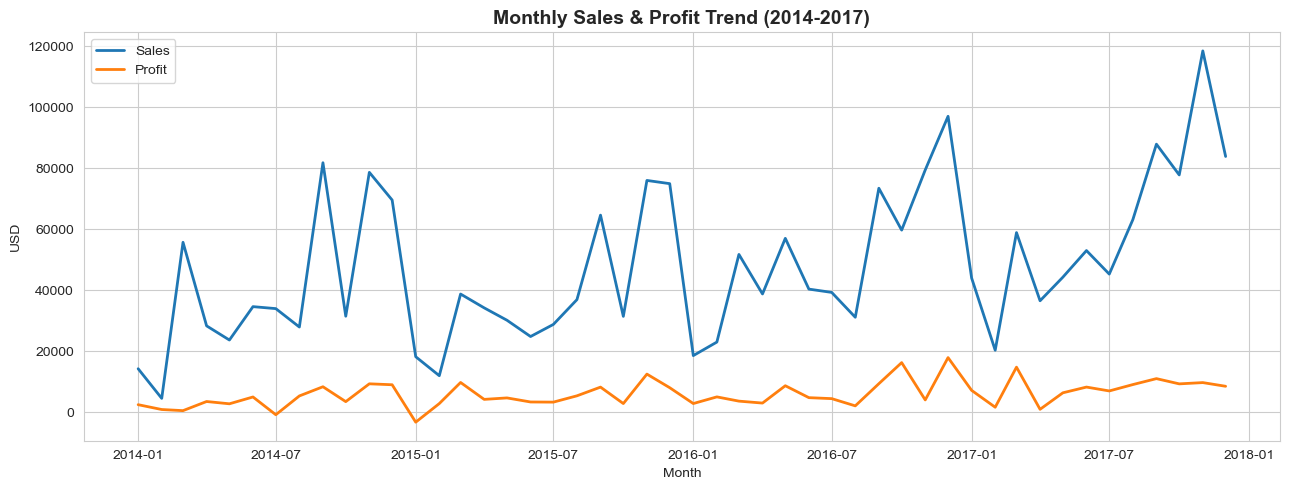

In [12]:
monthly = df.groupby("Order Month-Year")[["Sales","Profit"]].sum().reset_index()
monthly["Order Month-Year"] = pd.to_datetime(monthly["Order Month-Year"])
monthly = monthly.sort_values("Order Month-Year")

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(monthly["Order Month-Year"], monthly["Sales"], label="Sales", linewidth=2)
ax.plot(monthly["Order Month-Year"], monthly["Profit"], label="Profit", linewidth=2)
ax.set_title("Monthly Sales & Profit Trend (2014-2017)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("USD")
ax.legend()
plt.tight_layout()
plt.show()


### 3.3 Sales & Profit by Category

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


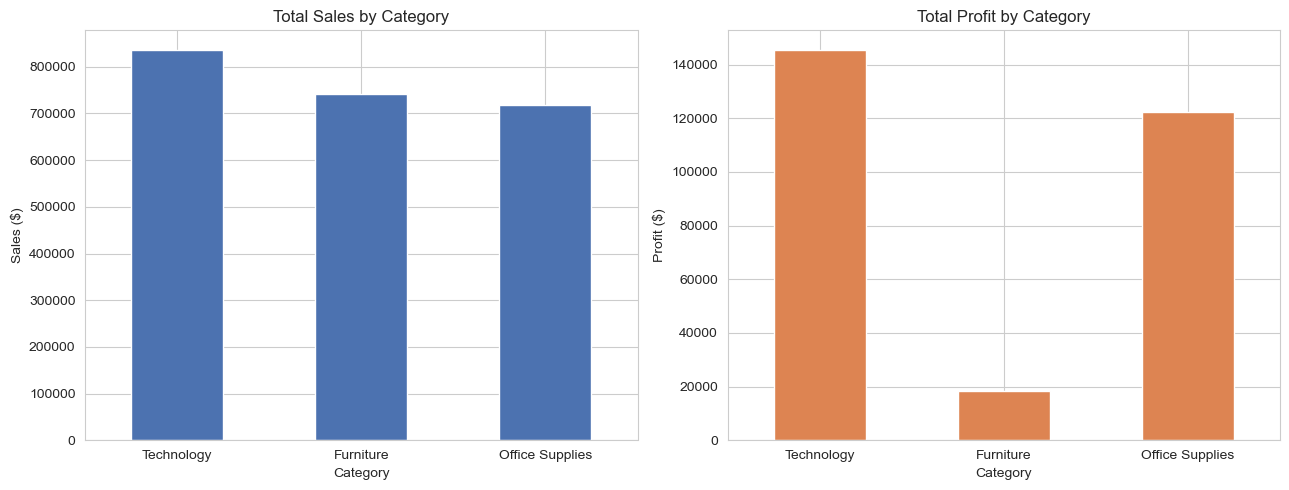

In [13]:
cat = df.groupby("Category")[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)
print(cat)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
cat["Sales"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Total Sales by Category"); axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis='x', rotation=0)

cat["Profit"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Total Profit by Category"); axes[1].set_ylabel("Profit ($)")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 3.4 Sub-Category Profitability — Where Are We Losing Money?

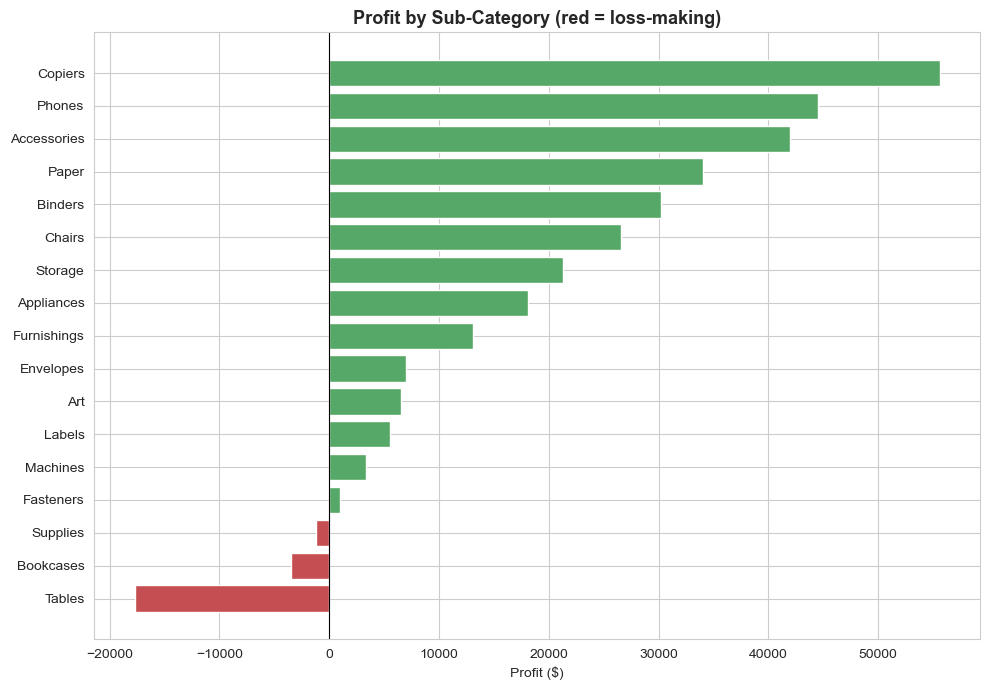

Loss-making sub-categories:
                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995


In [14]:
subcat = df.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values("Profit")

fig, ax = plt.subplots(figsize=(10,7))
colors = ["#C44E52" if v < 0 else "#55A868" for v in subcat["Profit"]]
ax.barh(subcat.index, subcat["Profit"], color=colors)
ax.set_title("Profit by Sub-Category (red = loss-making)", fontsize=13, fontweight="bold")
ax.set_xlabel("Profit ($)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Loss-making sub-categories:")
print(subcat[subcat["Profit"] < 0])


### 3.5 Regional Performance

               Sales       Profit  Margin %
Region                                     
West     725457.8245  108418.4489      14.9
East     678781.2400   91522.7800      13.5
Central  501239.8908   39706.3625       7.9
South    391721.9050   46749.4303      11.9


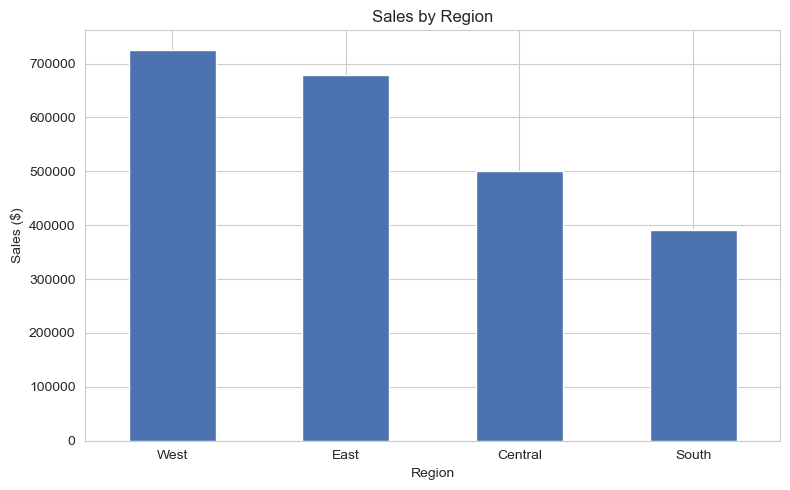

In [15]:
region = df.groupby("Region")[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)
region["Margin %"] = (region["Profit"]/region["Sales"]*100).round(1)
print(region)

fig, ax = plt.subplots(figsize=(8,5))
region["Sales"].plot(kind="bar", ax=ax, color="#4C72B0", label="Sales")
ax.set_title("Sales by Region"); ax.set_ylabel("Sales ($)")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


### 3.6 Discount vs Profit — Does Discounting Hurt Margin?

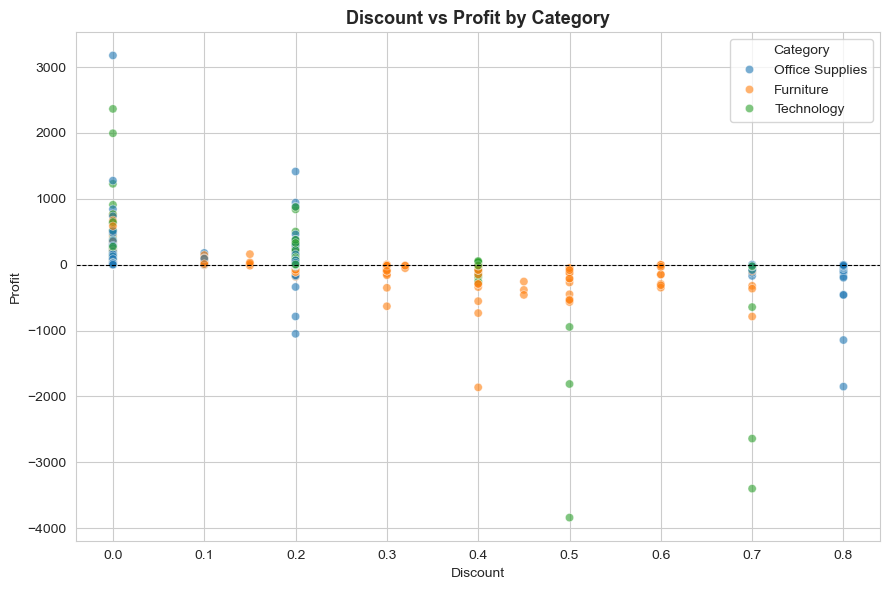

Correlation matrix:
          Sales  Quantity  Discount  Profit
Sales      1.00      0.20     -0.03    0.48
Quantity   0.20      1.00      0.01    0.07
Discount  -0.03      0.01      1.00   -0.22
Profit     0.48      0.07     -0.22    1.00


In [16]:
fig, ax = plt.subplots(figsize=(9,6))
sample = df.sample(min(2000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="Discount", y="Profit", hue="Category", alpha=0.6, ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Discount vs Profit by Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

corr = df[["Sales","Quantity","Discount","Profit"]].corr()
print("Correlation matrix:")
print(corr.round(2))


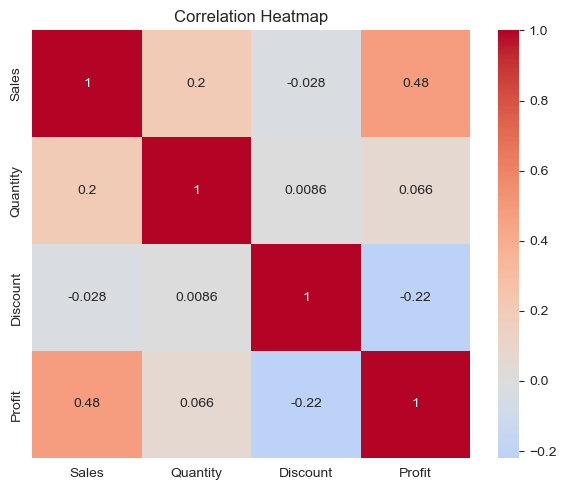

In [17]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(df[["Sales","Quantity","Discount","Profit"]].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 3.7 Top 10 Customers by Sales

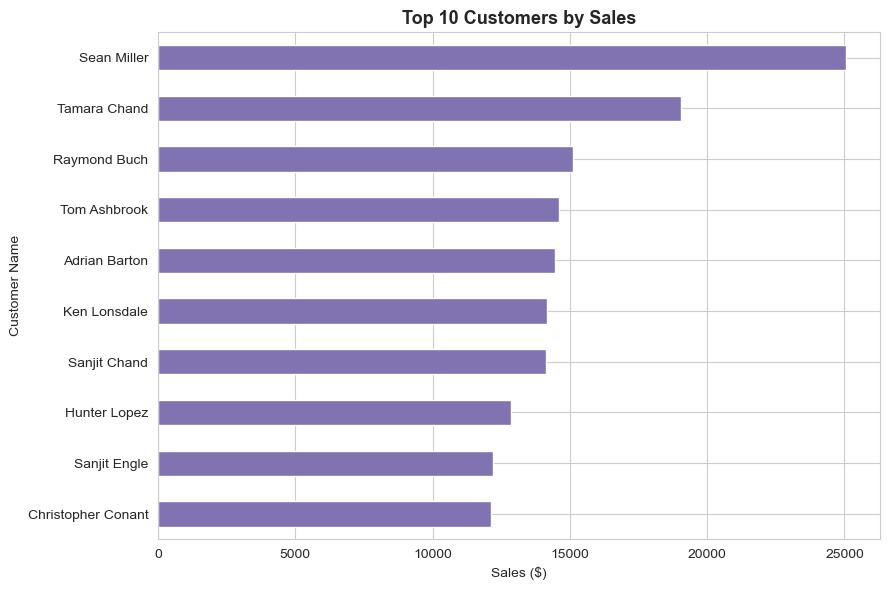

In [18]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9,6))
top_customers.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Top 10 Customers by Sales", fontsize=13, fontweight="bold")
ax.set_xlabel("Sales ($)")
plt.tight_layout()
plt.show()


### 3.8 Ship Mode & Fulfillment Time

                orders  avg_days
Ship Mode                       
Same Day           264       0.0
First Class        787       2.2
Second Class       964       3.2
Standard Class    2994       5.0


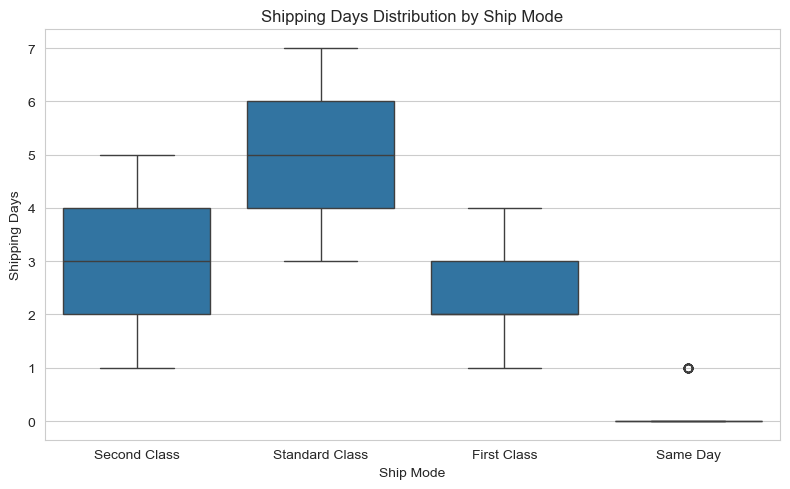

In [19]:
ship = df.groupby("Ship Mode").agg(orders=("Order ID","nunique"),
                                     avg_days=("Shipping Days","mean")).round(1)
print(ship.sort_values("avg_days"))

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="Ship Mode", y="Shipping Days", ax=ax)
ax.set_title("Shipping Days Distribution by Ship Mode")
plt.tight_layout()
plt.show()


## 4. SQL Analysis

Now we move the cleaned data into a **real relational database**. We'll use **SQLite** here because it needs zero setup and ships with Python — but every query below is standard SQL and will run unchanged on MySQL, PostgreSQL, or SQL Server (minor syntax tweaks aside, e.g. quoting identifiers).

We create one table, `orders`, matching the cleaned dataframe.


In [20]:
conn = sqlite3.connect("superstore.db")
df.to_sql("orders", conn, if_exists="replace", index=False)

# Quick sanity check
check = pd.read_sql("SELECT COUNT(*) AS row_count FROM orders;", conn)
print(check)


   row_count
0       9994


### 4.1 Sales & Profit by Category (SQL)

In [21]:
query1 = '''
SELECT
    Category,
    ROUND(SUM(Sales), 2)  AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(SUM(Profit)*100.0/SUM(Sales), 2) AS margin_pct
FROM orders
GROUP BY Category
ORDER BY total_sales DESC;
'''
pd.read_sql(query1, conn)


,Category,total_sales,total_profit,margin_pct
0,Technology,836154.03,145454.95,17.40
1,Furniture,741999.80,18451.27,2.49
2,Office Supplies,719047.03,122490.80,17.04


### 4.2 Year-over-Year Sales Growth

In [22]:
query2 = '''
SELECT
    "Order Year" AS year,
    ROUND(SUM(Sales), 2)  AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM orders
GROUP BY "Order Year"
ORDER BY year;
'''
yoy = pd.read_sql(query2, conn)
yoy["yoy_growth_pct"] = (yoy["total_sales"].pct_change()*100).round(1)
yoy


,year,total_sales,total_profit,yoy_growth_pct
0,2014,484247.50,49543.97,NaN
1,2015,470532.51,61618.60,-2.8
2,2016,609205.60,81795.17,29.5
3,2017,733215.26,93439.27,20.4


### 4.3 Top 5 Loss-Making (Region, Sub-Category) Combinations

In [23]:
query3 = '''
SELECT
    Region,
    "Sub-Category",
    ROUND(SUM(Profit), 2) AS total_profit,
    COUNT(*) AS num_orders
FROM orders
GROUP BY Region, "Sub-Category"
HAVING total_profit < 0
ORDER BY total_profit ASC
LIMIT 5;
'''
pd.read_sql(query3, conn)


,Region,Sub-Category,total_profit,num_orders
0,East,Tables,-11025.38,80
1,South,Tables,-4623.06,51
2,Central,Furnishings,-3906.22,205
3,Central,Tables,-3559.65,72
4,Central,Appliances,-2638.62,123


### 4.4 Top 10 Customers by Lifetime Sales

In [24]:
query4 = '''
SELECT
    "Customer Name",
    Segment,
    COUNT(DISTINCT "Order ID") AS num_orders,
    ROUND(SUM(Sales), 2)  AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM orders
GROUP BY "Customer Name", Segment
ORDER BY total_sales DESC
LIMIT 10;
'''
pd.read_sql(query4, conn)


,Customer Name,Segment,num_orders,total_sales,total_profit
0,Sean Miller,Home Office,5,25043.05,-1980.74
1,Tamara Chand,Corporate,5,19052.22,8981.32
2,Raymond Buch,Consumer,6,15117.34,6976.10
3,Tom Ashbrook,Home Office,4,14595.62,4703.79
4,Adrian Barton,Consumer,10,14473.57,5444.81
5,Ken Lonsdale,Consumer,12,14175.23,806.85
6,Sanjit Chand,Consumer,9,14142.33,5757.41
7,Hunter Lopez,Consumer,6,12873.30,5622.43
8,Sanjit Engle,Consumer,11,12209.44,2650.68
9,Christopher Conant,Consumer,5,12129.07,2177.05


### 4.5 Monthly Sales Trend (SQL window function style)

In [25]:
query5 = '''
SELECT
    "Order Month-Year" AS month,
    ROUND(SUM(Sales), 2) AS monthly_sales,
    ROUND(SUM(SUM(Sales)) OVER (ORDER BY "Order Month-Year"), 2) AS running_total
FROM orders
GROUP BY "Order Month-Year"
ORDER BY month
LIMIT 12;
'''
pd.read_sql(query5, conn)


,month,monthly_sales,running_total
0,2014-01,14236.90,14236.90
1,2014-02,4519.89,18756.79
2,2014-03,55691.01,74447.80
3,2014-04,28295.34,102743.14
4,2014-05,23648.29,126391.43
5,2014-06,34595.13,160986.56
6,2014-07,33946.39,194932.95
7,2014-08,27909.47,222842.42
8,2014-09,81777.35,304619.77
9,2014-10,31453.39,336073.16


### 4.6 Discount Impact — Average Discount vs Profit Margin by Category

In [26]:
query6 = '''
SELECT
    Category,
    ROUND(AVG(Discount), 3) AS avg_discount,
    ROUND(AVG("Profit Margin"), 3) AS avg_profit_margin
FROM orders
GROUP BY Category
ORDER BY avg_discount DESC;
'''
pd.read_sql(query6, conn)


,Category,avg_discount,avg_profit_margin
0,Furniture,0.174,0.039
1,Office Supplies,0.157,0.138
2,Technology,0.132,0.156


### 4.7 Best-Selling Products (by Quantity)

In [27]:
query7 = '''
SELECT
    "Product Name",
    Category,
    SUM(Quantity) AS total_units_sold,
    ROUND(SUM(Sales), 2) AS total_sales
FROM orders
GROUP BY "Product Name", Category
ORDER BY total_units_sold DESC
LIMIT 10;
'''
pd.read_sql(query7, conn)


,Product Name,Category,total_units_sold,total_sales
0,Staples,Office Supplies,215,755.47
1,Staple envelope,Office Supplies,170,1686.81
2,Easy-staple paper,Office Supplies,150,2504.19
3,Staples in misc. colors,Office Supplies,86,478.81
4,KI Adjustable-Height Table,Furniture,74,4552.64
5,Avery Non-Stick Binders,Office Supplies,71,217.32
6,Storex Dura Pro Binders,Office Supplies,71,278.59
7,GBC Premium Transparent Covers with Diagonal L...,Office Supplies,67,780.46
8,"Situations Contoured Folding Chairs, 4/Set",Furniture,64,3641.27
9,Staple-based wall hangings,Furniture,62,422.29


In [28]:
conn.close()
print("SQLite connection closed. Database saved as 'superstore.db'")


SQLite connection closed. Database saved as 'superstore.db'


## 5. Export for Power BI

Power BI can connect directly to `superstore.db` (via an ODBC/SQLite connector) or, more simply, to a clean Excel file. We'll export both the flat cleaned table for a quick start.


In [29]:
df.to_excel("Superstore_Cleaned.xlsx", index=False, sheet_name="Orders")
print("Saved: Superstore_Cleaned.xlsx  -> ready to import into Power BI")
print(f"Final shape: {df.shape}")


Saved: Superstore_Cleaned.xlsx  -> ready to import into Power BI
Final shape: (9994, 27)


## 6. Key Insights Summary

Based on the EDA and SQL analysis above:

1. **Technology** has the highest profit margin of the three categories; **Furniture** generates strong sales but the *weakest* profit margin — it's dragging down overall profitability.
2. **Tables** and **Bookcases** (Furniture) and **Supplies** (Office Supplies) are consistently loss-making across multiple regions — prime candidates for repricing or discount-policy review.
3. Sales grew every year from 2014 to 2017, with 2017 the strongest year on record.
4. Higher discount rates correlate with negative profit — orders discounted above ~30% are frequently unprofitable, regardless of category.
5. A small group of top-10 customers accounts for a disproportionate share of total sales — a good target list for loyalty/retention campaigns.
6. `Standard Class` shipping is used most often but has the longest average fulfillment time; `Same Day` is fastest but rare.

**Next step:** Build an interactive Power BI dashboard on top of `Superstore_Cleaned.xlsx` / `superstore.db` — see the accompanying **Power BI Dashboard Guide** for step-by-step instructions, DAX measures, and layout recommendations.


In [30]:
import pyodbc
from sqlalchemy import create_engine
import urllib

# SQL Server details
server = r"localhost\SQL2025"
database = "Superstore_Analysis"

# Windows Authentication
connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

# Encode connection string
encoded_conn = urllib.parse.quote_plus(connection_string)

# Create SQLAlchemy engine
engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={encoded_conn}"
)

# Upload DataFrame
df.to_sql(
    "customer",
    con=engine,
    if_exists="replace",
    index=False
)

print("Table 'customer' uploaded successfully!")

Table 'customer' uploaded successfully!


In [31]:
print(df.columns.tolist())
print(df.shape)

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month Num', 'Order Month', 'Order Month-Year', 'Shipping Days', 'Profit Margin']
(9994, 27)


In [32]:
check = pd.read_sql("SELECT COUNT(*) AS row_count FROM customer;", engine)
print(check)

preview = pd.read_sql("SELECT TOP 5 * FROM customer;", engine)
print(preview)

   row_count
0       9994
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product 